# Offline benchmark на dataset v2

Этот ноутбук является продолжением `01_dataset_v2_audit.ipynb`.

Здесь уже можно сравнивать модели, потому что перед этим были разделены задачи:

- day-level offline dataset для ML benchmark;
- production replay dataset для monitor/backtest;
- feature registry и исключение post-fact/source metadata;
- отдельная пометка visibility как coverage-risk признака.

Цель ноутбука: честно сравнить простые ML-кандидаты и baseline-ы на `training_dataset_v2_day.csv`, не смешивая это с production ledger.

Правила протокола:

- train/valid/test берутся из dataset v2;
- hyperparameter/threshold selection делается только на validation;
- test используется один раз для финальной оценки выбранной конфигурации;
- основной вероятностный критерий — Brier Score и калибровка;
- `production baseline proxy` остается только диагностическим proxy, потому что использует дневные historical weather aggregates, а не настоящий forecast weather-window.

In [1]:
from pathlib import Path
import json
import math
import sys
import warnings

from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("png")
except Exception:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

for candidate in (PROJECT_ROOT, PROJECT_ROOT / "backend"):
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from app.schemas import HistoricalSnapshot, WeatherSnapshot
from app.services.predictor import MODEL_VERSION, calculate_probability, make_decision

DATASET_V2_DAY_PATH = PROJECT_ROOT / "data" / "processed" / "training_dataset_v2_day.csv"
RECOMMENDED_FEATURES_PATH = PROJECT_ROOT / "data" / "interim" / "training" / "dataset_v2_audit" / "recommended_feature_sets.json"
OUTPUT_DIR = PROJECT_ROOT / "data" / "interim" / "training" / "offline_benchmark_v2"
METRICS_PATH = OUTPUT_DIR / "offline_benchmark_v2_metrics.csv"
PREDICTIONS_PATH = OUTPUT_DIR / "offline_benchmark_v2_predictions.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("dataset:", DATASET_V2_DAY_PATH)
print("feature_sets:", RECOMMENDED_FEATURES_PATH)
print("backend_model_version_for_proxy:", MODEL_VERSION)

dataset: C:\Users\Владимир Королев\PycharmProjects\flyforecast\data\processed\training_dataset_v2_day.csv
feature_sets: C:\Users\Владимир Королев\PycharmProjects\flyforecast\data\interim\training\dataset_v2_audit\recommended_feature_sets.json
backend_model_version_for_proxy: mvp-baseline-007


## 1. Загрузка dataset v2

Dataset v2 был собран в предыдущем ноутбуке. Здесь не пересобираем признаки, а используем зафиксированный результат аудита.

In [2]:
df = pd.read_csv(DATASET_V2_DAY_PATH, parse_dates=["date"])
with RECOMMENDED_FEATURES_PATH.open("r", encoding="utf-8") as file:
    feature_sets = json.load(file)

target = "is_flight_completed"
required_cols = {"date", target, "dataset_split"}
missing_required = required_cols - set(df.columns)
if missing_required:
    raise ValueError(f"dataset v2 is missing required columns: {missing_required}")

for key, values in feature_sets.items():
    if key.endswith("features"):
        missing = sorted(set(values) - set(df.columns))
        if missing:
            raise ValueError(f"feature set {key} has missing columns: {missing[:10]}")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Date range: {df['date'].min().date()} .. {df['date'].max().date()}")
display(df["dataset_split"].value_counts())

display(
    df.groupby("dataset_split", sort=False)
    .agg(rows=(target, "size"), completion_rate=(target, "mean"))
    .round(4)
)

Rows: 761
Columns: 98
Date range: 2017-12-13 .. 2026-05-26


dataset_split
train    532
test     115
valid    114
Name: count, dtype: int64

,rows,completion_rate
dataset_split,,
train,532,0.6635
valid,114,0.2632
test,115,0.2435


## 2. Feature sets

`full_v2` — все признаки, разрешенные audit notebook-ом.

`no_visibility_v2` — тот же набор без visibility. Это обязательная проверка, потому что visibility в v1/v2 имеет coverage drift: в train есть пропуски, а в valid/test она заполнена полностью.

In [3]:
feature_set_specs = {
    "full_v2": feature_sets["day_level_v2_features"],
    "no_visibility_v2": feature_sets["day_level_v2_no_visibility_features"],
}

for name, cols in feature_set_specs.items():
    cat_cols = df[cols].select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [col for col in cols if col not in cat_cols]
    print(f"{name}: total={len(cols)}, numeric={len(num_cols)}, categorical={len(cat_cols)}")
    if cat_cols:
        print("  categorical:", cat_cols)

full_v2: total=95, numeric=92, categorical=3
  categorical: ['season', 'khomutovo_fog_low_cloud_risk_level', 'mendeleyevo_fog_low_cloud_risk_level']
no_visibility_v2: total=91, numeric=88, categorical=3
  categorical: ['season', 'khomutovo_fog_low_cloud_risk_level', 'mendeleyevo_fog_low_cloud_risk_level']


## 3. Метрики и threshold tuning

Каждая модель возвращает вероятность `completed`. Порог для `Да/Нет` выбираем только на validation.

Для продукта нельзя смотреть только на accuracy. Поэтому считаем:

- Brier Score;
- ROC-AUC;
- PR-AUC по отменам;
- balanced accuracy;
- precision/recall/F1 по отменам и выполненным;
- false yes и false no.

`quality_score` — не бизнес-метрика, а ranking heuristic для offline selection. Веса в нём помогают сортировать эксперименты, но не заменяют продуктовые ограничения по `false_yes`, `false_no`, Brier Score и калибровке.


In [4]:
def safe_roc_auc(y_true, proba):
    return roc_auc_score(y_true, proba) if len(np.unique(y_true)) == 2 else np.nan


def safe_pr_auc_cancelled(y_true, proba_completed):
    y_cancelled = 1 - np.asarray(y_true)
    proba_cancelled = 1 - np.asarray(proba_completed)
    return average_precision_score(y_cancelled, proba_cancelled) if len(np.unique(y_cancelled)) == 2 else np.nan


def predict_by_threshold(proba_completed, threshold):
    return (np.asarray(proba_completed) >= threshold).astype(int)


def metric_row(model, feature_set, split, y_true, proba_completed, threshold, selected_on="validation"):
    y_true = np.asarray(y_true).astype(int)
    proba_completed = np.asarray(proba_completed).astype(float)
    pred = predict_by_threshold(proba_completed, threshold)
    cancelled_true = 1 - y_true
    cancelled_pred = 1 - pred

    false_yes = int(((pred == 1) & (y_true == 0)).sum())
    false_no = int(((pred == 0) & (y_true == 1)).sum())

    row = {
        "model": model,
        "feature_set": feature_set,
        "split": split,
        "threshold": round(float(threshold), 4),
        "selected_on": selected_on,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "roc_auc": safe_roc_auc(y_true, proba_completed),
        "pr_auc_cancelled": safe_pr_auc_cancelled(y_true, proba_completed),
        "brier_score": brier_score_loss(y_true, proba_completed),
        "f1_cancelled": f1_score(cancelled_true, cancelled_pred, zero_division=0),
        "precision_cancelled": precision_score(cancelled_true, cancelled_pred, zero_division=0),
        "recall_cancelled": recall_score(cancelled_true, cancelled_pred, zero_division=0),
        "f1_completed": f1_score(y_true, pred, zero_division=0),
        "precision_completed": precision_score(y_true, pred, zero_division=0),
        "recall_completed": recall_score(y_true, pred, zero_division=0),
        "false_yes": false_yes,
        "false_no": false_no,
        "support_cancelled": int(cancelled_true.sum()),
        "support_completed": int(y_true.sum()),
        "mean_probability_completed": float(proba_completed.mean()),
        "observed_completion_rate": float(y_true.mean()),
    }
    row["quality_score"] = (
        0.30 * row["roc_auc"]
        + 0.25 * row["balanced_accuracy"]
        + 0.15 * row["f1_cancelled"]
        + 0.15 * row["f1_completed"]
        + 0.15 * (1 - row["brier_score"])
    )
    return row


def tune_threshold_on_validation(model, feature_set, y_valid, valid_proba):
    candidates = np.round(np.arange(0.05, 0.951, 0.01), 2)
    rows = [
        metric_row(model, feature_set, "valid", y_valid, valid_proba, threshold, selected_on="validation")
        for threshold in candidates
    ]
    ranked = sorted(
        rows,
        key=lambda row: (
            row["quality_score"],
            -row["false_yes"],
            -abs(row["mean_probability_completed"] - row["observed_completion_rate"]),
        ),
        reverse=True,
    )
    return ranked[0]["threshold"], pd.DataFrame(rows)


def class_proba_completed(model, X_part):
    proba = model.predict_proba(X_part)
    classes = list(model.classes_) if hasattr(model, "classes_") else list(model.named_steps["model"].classes_)
    return proba[:, classes.index(1)]

## 4. Baseline probabilities

Baseline-ы тоже проходят через validation threshold tuning, кроме diagnostic business-threshold строки для production proxy.

Важно: `Current production baseline daily proxy` не является настоящим production baseline. Это попытка применить backend formula к day-level historical aggregates. Настоящая проверка production baseline должна жить в production replay notebook.

In [5]:
def safe_probability(completed, total, fallback=0.5):
    if total <= 0:
        return fallback
    return round((completed + 1) / (total + 2), 4)


def circular_distance(day_a, day_b):
    raw = abs(day_a - day_b)
    return min(raw, 366 - raw)


def history_snapshot_until_date(target_date, history_df):
    past = history_df[history_df["date"] < target_date]
    if past.empty:
        return HistoricalSnapshot(
            source="dataset_v2_past_only",
            similar_days_count=0,
            completed_count=0,
            cancelled_count=0,
            historical_probability_flight=0.5,
            month_probability_flight=None,
            decade_probability_flight=None,
        )

    month_rows = past[past["date"].dt.month == target_date.month]
    decade = (target_date.day - 1) // 10 + 1
    decade_rows = past[
        (past["date"].dt.month == target_date.month)
        & (((past["date"].dt.day - 1) // 10 + 1) == decade)
    ]

    target_doy = target_date.timetuple().tm_yday
    similar_rows = past[
        past["date"].dt.dayofyear.apply(lambda day: circular_distance(int(day), target_doy) <= 14)
    ]
    if len(similar_rows) < 10:
        similar_rows = month_rows

    completed_count = int(similar_rows[target].sum()) if len(similar_rows) else 0
    cancelled_count = int(len(similar_rows) - completed_count)
    month_completed = int(month_rows[target].sum()) if len(month_rows) else 0
    decade_completed = int(decade_rows[target].sum()) if len(decade_rows) else 0

    return HistoricalSnapshot(
        source="dataset_v2_past_only",
        similar_days_count=len(similar_rows),
        completed_count=completed_count,
        cancelled_count=cancelled_count,
        historical_probability_flight=safe_probability(completed_count, len(similar_rows)),
        month_probability_flight=safe_probability(month_completed, len(month_rows)) if len(month_rows) else None,
        decade_probability_flight=safe_probability(decade_completed, len(decade_rows)) if len(decade_rows) else None,
    )


def optional_float(row, column):
    value = row.get(column, np.nan)
    return None if pd.isna(value) else float(value)


def optional_str(row, column):
    value = row.get(column, None)
    return None if pd.isna(value) else str(value)


def daily_proxy_flight_window_available(row):
    wind_gusts = optional_float(row, "mendeleyevo_wind_gusts_10m_max")
    precipitation = optional_float(row, "mendeleyevo_precipitation_sum")
    weather_code = optional_float(row, "mendeleyevo_weather_code_mode")
    if wind_gusts is not None and wind_gusts > 65:
        return False
    if precipitation is not None and precipitation > 2.5:
        return False
    if weather_code is not None and int(weather_code) in {45, 48}:
        return False
    return True


def weather_snapshot_from_day_row(row):
    return WeatherSnapshot(
        source="dataset-v2-day-actual-weather-proxy",
        available=True,
        temperature_2m=optional_float(row, "mendeleyevo_temperature_2m_mean"),
        relative_humidity_2m=optional_float(row, "mendeleyevo_relative_humidity_2m_mean"),
        dew_point_2m=optional_float(row, "mendeleyevo_dew_point_2m_mean"),
        dew_point_spread=optional_float(row, "mendeleyevo_dew_point_spread_mean"),
        pressure_msl=optional_float(row, "mendeleyevo_pressure_msl_mean"),
        cloud_cover=optional_float(row, "mendeleyevo_cloud_cover_mean"),
        cloud_cover_low=optional_float(row, "mendeleyevo_cloud_cover_low_mean"),
        precipitation=optional_float(row, "mendeleyevo_precipitation_sum"),
        wind_speed_10m=optional_float(row, "mendeleyevo_wind_speed_10m_mean"),
        wind_gusts_10m=optional_float(row, "mendeleyevo_wind_gusts_10m_max"),
        weather_code=optional_float(row, "mendeleyevo_weather_code_mode"),
        visibility=optional_float(row, "mendeleyevo_visibility_min"),
        fog_low_cloud_risk_score=optional_float(row, "mendeleyevo_fog_low_cloud_risk_score"),
        fog_low_cloud_risk_level=optional_str(row, "mendeleyevo_fog_low_cloud_risk_level"),
        aggregation_window_start_hour=8,
        aggregation_window_end_hour=20,
        aggregation_window_hours=13,
        flight_window_available=daily_proxy_flight_window_available(row),
    )


def seasonal_history_proba(rows, history_df):
    probs = []
    for _, row in rows.iterrows():
        history = history_snapshot_until_date(row["date"], history_df)
        probability = history.historical_probability_flight
        if history.decade_probability_flight is not None:
            probability = 0.65 * history.historical_probability_flight + 0.35 * history.decade_probability_flight
        probs.append(round(float(probability), 4))
    return np.array(probs)


def production_baseline_proxy_proba(rows, history_df):
    probs = []
    for _, row in rows.iterrows():
        history = history_snapshot_until_date(row["date"], history_df)
        weather = weather_snapshot_from_day_row(row)
        probs.append(calculate_probability(horizon_days=0, weather=weather, history=history))
    return np.array(probs)

## 5. ML pipelines

Для RandomForest используем небольшой validation search, а не тяжелый полный GridSearch. Это сохраняет честность selection protocol: все параметры выбираются по validation, test не используется до финального отчета.

In [6]:
train_df = df[df["dataset_split"] == "train"].copy()
valid_df = df[df["dataset_split"] == "valid"].copy()
test_df = df[df["dataset_split"] == "test"].copy()

y_train = train_df[target].astype(int).to_numpy()
y_valid = valid_df[target].astype(int).to_numpy()
y_test = test_df[target].astype(int).to_numpy()


def make_preprocessor(X_fit):
    cat_cols = X_fit.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [col for col in X_fit.columns if col not in cat_cols]
    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ]
    )


def make_model(kind, X_fit, params=None):
    params = params or {}
    if kind == "logistic_regression":
        estimator = LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear", **params)
    elif kind == "decision_tree":
        estimator = DecisionTreeClassifier(class_weight="balanced", random_state=42, **params)
    elif kind == "random_forest":
        estimator = RandomForestClassifier(class_weight="balanced_subsample", random_state=42, n_jobs=-1, **params)
    else:
        raise ValueError(kind)
    return Pipeline(steps=[("prep", make_preprocessor(X_fit)), ("model", estimator)])


def fit_and_score_model(model_name, feature_set_name, kind, params=None):
    cols = feature_set_specs[feature_set_name]
    X_train = train_df[cols]
    X_valid = valid_df[cols]
    X_test = test_df[cols]
    model = make_model(kind, X_train, params=params)
    model.fit(X_train, y_train)
    valid_proba = class_proba_completed(model, X_valid)
    threshold, threshold_table = tune_threshold_on_validation(model_name, feature_set_name, y_valid, valid_proba)
    test_proba = class_proba_completed(model, X_test)
    rows = [
        metric_row(model_name, feature_set_name, "valid", y_valid, valid_proba, threshold),
        metric_row(model_name, feature_set_name, "test", y_test, test_proba, threshold),
    ]
    return model, rows, threshold_table

## 6. Запуск benchmark

Сначала считаем baseline probabilities, затем ML-кандидатов на двух feature sets.

In [7]:
metric_rows = []
prediction_rows = []
threshold_diagnostics = []
fitted_models = {}

# Baselines.
constant_proba_valid = np.full_like(y_valid, fill_value=y_train.mean(), dtype=float)
constant_proba_test = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
seasonal_proba_valid = seasonal_history_proba(valid_df, df)
seasonal_proba_test = seasonal_history_proba(test_df, df)
proxy_proba_valid = production_baseline_proxy_proba(valid_df, df)
proxy_proba_test = production_baseline_proxy_proba(test_df, df)

baseline_specs = [
    ("Constant train-rate baseline", "baseline", constant_proba_valid, constant_proba_test),
    ("Seasonal history baseline", "baseline", seasonal_proba_valid, seasonal_proba_test),
    ("Current production baseline daily proxy", "diagnostic_proxy", proxy_proba_valid, proxy_proba_test),
]

for model_name, feature_set_name, valid_proba, test_proba in baseline_specs:
    threshold, threshold_table = tune_threshold_on_validation(model_name, feature_set_name, y_valid, valid_proba)
    threshold_diagnostics.append(threshold_table.assign(model=model_name, feature_set=feature_set_name))
    metric_rows.append(metric_row(model_name, feature_set_name, "valid", y_valid, valid_proba, threshold))
    metric_rows.append(metric_row(model_name, feature_set_name, "test", y_test, test_proba, threshold))

    for split, split_df, y_part, proba in [
        ("valid", valid_df, y_valid, valid_proba),
        ("test", test_df, y_test, test_proba),
    ]:
        pred = predict_by_threshold(proba, threshold)
        prediction_rows.extend(
            {
                "model": model_name,
                "feature_set": feature_set_name,
                "split": split,
                "date": date,
                "y_true": int(y),
                "probability_completed": float(p),
                "threshold": float(threshold),
                "prediction": int(pr),
            }
            for date, y, p, pr in zip(split_df["date"], y_part, proba, pred)
        )

# Diagnostic production proxy with business threshold used by backend for horizon 0.
business_threshold = 0.55
metric_rows.append(
    metric_row(
        "Current production baseline daily proxy business threshold",
        "diagnostic_proxy",
        "valid",
        y_valid,
        proxy_proba_valid,
        business_threshold,
        selected_on="fixed_business_rule",
    )
)
metric_rows.append(
    metric_row(
        "Current production baseline daily proxy business threshold",
        "diagnostic_proxy",
        "test",
        y_test,
        proxy_proba_test,
        business_threshold,
        selected_on="fixed_business_rule",
    )
)

# Deterministic ML candidates.
for feature_set_name in feature_set_specs:
    for model_name, kind, params in [
        ("Logistic Regression", "logistic_regression", {}),
        ("Decision Tree shallow", "decision_tree", {"max_depth": 3, "min_samples_leaf": 20}),
    ]:
        model, rows, threshold_table = fit_and_score_model(model_name, feature_set_name, kind, params=params)
        fitted_models[(model_name, feature_set_name)] = model
        metric_rows.extend(rows)
        threshold_diagnostics.append(threshold_table.assign(model=model_name, feature_set=feature_set_name))

# Small validation search for RandomForest.
rf_grid = [
    {"n_estimators": 200, "max_depth": 4, "min_samples_leaf": 5},
    {"n_estimators": 200, "max_depth": 4, "min_samples_leaf": 15},
    {"n_estimators": 200, "max_depth": 8, "min_samples_leaf": 5},
    {"n_estimators": 200, "max_depth": 8, "min_samples_leaf": 15},
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 5},
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 15},
]

rf_selection_rows = []
for feature_set_name in feature_set_specs:
    candidate_results = []
    for params in rf_grid:
        candidate_name = "RandomForest validation search"
        model, rows, threshold_table = fit_and_score_model(candidate_name, feature_set_name, "random_forest", params=params)
        valid_row = [row for row in rows if row["split"] == "valid"][0]
        candidate_results.append((valid_row["quality_score"], valid_row, model, rows, threshold_table, params))
        rf_selection_rows.append({**valid_row, **{f"param_{k}": v for k, v in params.items()}})

    candidate_results.sort(key=lambda item: item[0], reverse=True)
    _, _, best_model, best_rows, best_threshold_table, best_params = candidate_results[0]
    final_name = f"RandomForest selected ({feature_set_name})"
    for row in best_rows:
        row["model"] = final_name
        row["selected_params"] = json.dumps(best_params, ensure_ascii=False)
    metric_rows.extend(best_rows)
    threshold_diagnostics.append(best_threshold_table.assign(model=final_name, feature_set=feature_set_name))
    fitted_models[(final_name, feature_set_name)] = best_model

metrics = pd.DataFrame(metric_rows)
metrics.to_csv(METRICS_PATH, index=False, encoding="utf-8-sig")
predictions = pd.DataFrame(prediction_rows)
predictions.to_csv(PREDICTIONS_PATH, index=False, encoding="utf-8-sig")
rf_selection = pd.DataFrame(rf_selection_rows)

print("metrics:", METRICS_PATH)
print("predictions:", PREDICTIONS_PATH)
print("rows:", len(metrics))

metrics: C:\Users\Владимир Королев\PycharmProjects\flyforecast\data\interim\training\offline_benchmark_v2\offline_benchmark_v2_metrics.csv
predictions: C:\Users\Владимир Королев\PycharmProjects\flyforecast\data\interim\training\offline_benchmark_v2\offline_benchmark_v2_predictions.csv
rows: 20


## 7. Результаты validation/test

Сортировка внутри split идёт по `quality_score`. Победителя выбираем по validation, а test читаем как финальную проверку этой выбранной логики.

In [8]:
metrics_display = metrics.copy()
round_cols = [
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "pr_auc_cancelled",
    "brier_score",
    "f1_cancelled",
    "f1_completed",
    "precision_cancelled",
    "recall_cancelled",
    "precision_completed",
    "recall_completed",
    "mean_probability_completed",
    "observed_completion_rate",
    "quality_score",
]
for col in round_cols:
    if col in metrics_display.columns:
        metrics_display[col] = metrics_display[col].round(4)
metrics_display = (
    metrics_display.assign(_split_order=metrics_display["split"].map({"valid": 0, "test": 1}))
    .sort_values(["_split_order", "quality_score"], ascending=[True, False])
    .drop(columns="_split_order")
)
display(metrics_display)

valid_rank = metrics[metrics["split"] == "valid"].sort_values("quality_score", ascending=False)
best_valid = valid_rank.iloc[0]
best_model = best_valid["model"]
best_feature_set = best_valid["feature_set"]
print("Best by validation quality_score:", best_model, "/", best_feature_set)

test_for_best = metrics[
    (metrics["split"] == "test")
    & (metrics["model"] == best_model)
    & (metrics["feature_set"] == best_feature_set)
]
display(test_for_best[metrics_display.columns].round(4))

,model,feature_set,split,threshold,selected_on,accuracy,balanced_accuracy,roc_auc,pr_auc_cancelled,brier_score,...,precision_completed,recall_completed,false_yes,false_no,support_cancelled,support_completed,mean_probability_completed,observed_completion_rate,quality_score,selected_params
18,RandomForest selected (no_visibility_v2),no_visibility_v2,valid,0.49,validation,0.7719,0.6631,0.6651,0.8462,0.1988,...,0.5909,0.4333,9,17,84,30,0.3948,0.2632,0.6883,"{""n_estimators"": 200, ""max_depth"": 8, ""min_sam..."
16,RandomForest selected (full_v2),full_v2,valid,0.51,validation,0.7807,0.6369,0.6488,0.8355,0.2017,...,0.6667,0.3333,5,20,84,30,0.3971,0.2632,0.6698,"{""n_estimators"": 200, ""max_depth"": 8, ""min_sam..."
4,Current production baseline daily proxy,diagnostic_proxy,valid,0.44,validation,0.6228,0.6262,0.6294,0.8269,0.2260,...,0.3725,0.6333,32,11,84,30,0.4335,0.2632,0.6380,NaN
6,Current production baseline daily proxy busine...,diagnostic_proxy,valid,0.55,fixed_business_rule,0.6404,0.5417,0.6294,0.8269,0.2260,...,0.3226,0.3333,21,20,84,30,0.4335,0.2632,0.6027,NaN
10,Decision Tree shallow,full_v2,valid,0.32,validation,0.5702,0.5798,0.5968,0.7822,0.2242,...,0.3273,0.6000,37,12,84,30,0.4022,0.2632,0.6025,NaN
14,Decision Tree shallow,no_visibility_v2,valid,0.32,validation,0.5702,0.5798,0.5968,0.7822,0.2242,...,0.3273,0.6000,37,12,84,30,0.4022,0.2632,0.6025,NaN
12,Logistic Regression,no_visibility_v2,valid,0.21,validation,0.5175,0.5548,0.5524,0.8032,0.2603,...,0.3016,0.6333,44,11,84,30,0.3288,0.2632,0.5655,NaN
8,Logistic Regression,full_v2,valid,0.15,validation,0.4912,0.5798,0.5409,0.8002,0.2663,...,0.3108,0.7667,51,7,84,30,0.3250,0.2632,0.5634,NaN
0,Constant train-rate baseline,baseline,valid,0.67,validation,0.7368,0.5000,0.5000,0.7368,0.3542,...,0.0000,0.0000,0,30,84,30,0.6635,0.2632,0.4991,NaN
2,Seasonal history baseline,baseline,valid,0.79,validation,0.7368,0.5000,0.4016,0.7136,0.3312,...,0.0000,0.0000,0,30,84,30,0.6071,0.2632,0.4731,NaN


Best by validation quality_score: RandomForest selected (no_visibility_v2) / no_visibility_v2


,model,feature_set,split,threshold,selected_on,accuracy,balanced_accuracy,roc_auc,pr_auc_cancelled,brier_score,...,precision_completed,recall_completed,false_yes,false_no,support_cancelled,support_completed,mean_probability_completed,observed_completion_rate,quality_score,selected_params
19,RandomForest selected (no_visibility_v2),no_visibility_v2,test,0.49,validation,0.7826,0.6626,0.6839,0.85,0.1857,...,0.5714,0.4286,9,16,87,28,0.382,0.2435,0.6957,"{""n_estimators"": 200, ""max_depth"": 8, ""min_sam..."


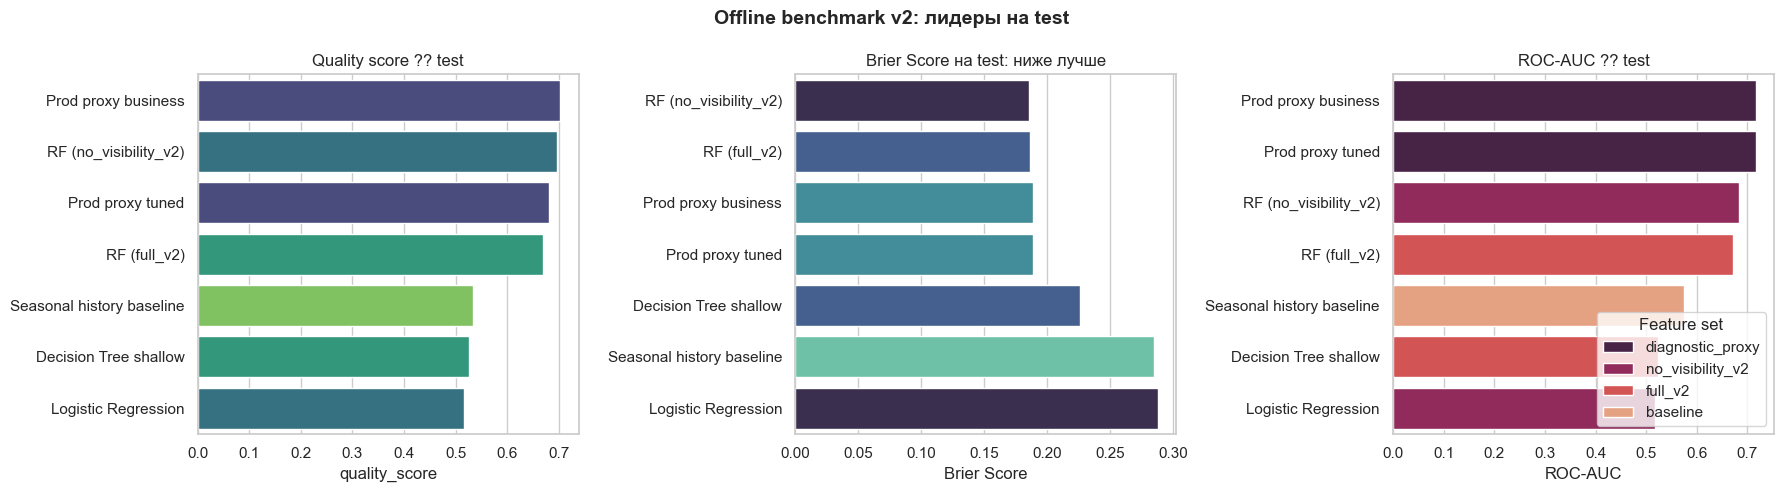

In [9]:
# Benchmark leaderboard visuals
test_leaderboard = metrics[metrics["split"] == "test"].copy()
test_leaderboard["short_model"] = test_leaderboard["model"].str.replace("Current production baseline daily proxy business threshold", "Prod proxy business", regex=False)
test_leaderboard["short_model"] = test_leaderboard["short_model"].str.replace("Current production baseline daily proxy", "Prod proxy tuned", regex=False)
test_leaderboard["short_model"] = test_leaderboard["short_model"].str.replace("RandomForest selected ", "RF ", regex=False)
plot_top = test_leaderboard.sort_values("quality_score", ascending=False).head(8).copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=plot_top, y="short_model", x="quality_score", hue="feature_set", dodge=False, palette="viridis", ax=axes[0])
axes[0].set_title("Quality score ?? test")
axes[0].set_xlabel("quality_score")
axes[0].set_ylabel("")
axes[0].legend_.remove()

s2 = plot_top.sort_values("brier_score", ascending=True)
sns.barplot(data=s2, y="short_model", x="brier_score", hue="feature_set", dodge=False, palette="mako", ax=axes[1])
axes[1].set_title("Brier Score на test: ниже лучше")
axes[1].set_xlabel("Brier Score")
axes[1].set_ylabel("")
axes[1].legend_.remove()

s3 = plot_top.sort_values("roc_auc", ascending=False)
sns.barplot(data=s3, y="short_model", x="roc_auc", hue="feature_set", dodge=False, palette="rocket", ax=axes[2])
axes[2].set_title("ROC-AUC ?? test")
axes[2].set_xlabel("ROC-AUC")
axes[2].set_ylabel("")
axes[2].legend(title="Feature set", loc="lower right")

fig.suptitle("Offline benchmark v2: лидеры на test", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Разделение offline models и diagnostic baselines

Таблица выше сортирует все строки вместе, но методологически это разные группы. Ниже они разведены явно:

- **true offline models/baselines** — честно сравнимы внутри day-level dataset v2;
- **diagnostic production proxy** — полезен как ориентир текущей production-логики, но не равен production replay и не должен трактоваться как финальное сравнение с `mvp-baseline-007`.

In [10]:
def benchmark_group(row):
    if row["feature_set"] == "diagnostic_proxy":
        return "diagnostic production proxy"
    if row["feature_set"] == "baseline":
        return "offline baseline"
    return "offline ML candidate"

metrics_grouped = metrics.copy()
metrics_grouped["benchmark_group"] = metrics_grouped.apply(benchmark_group, axis=1)

group_cols = [
    "benchmark_group",
    "model",
    "feature_set",
    "split",
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "pr_auc_cancelled",
    "brier_score",
    "false_yes",
    "false_no",
    "quality_score",
]

for group_name in ["offline ML candidate", "offline baseline", "diagnostic production proxy"]:
    subset = metrics_grouped[(metrics_grouped["split"] == "test") & (metrics_grouped["benchmark_group"] == group_name)]
    print(group_name)
    display(subset[group_cols].sort_values("quality_score", ascending=False).round(4))

offline ML candidate


,benchmark_group,model,feature_set,split,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc_cancelled,brier_score,false_yes,false_no,quality_score
19,offline ML candidate,RandomForest selected (no_visibility_v2),no_visibility_v2,test,0.49,0.7826,0.6626,0.6839,0.8500,0.1857,9,16,0.6957
17,offline ML candidate,RandomForest selected (full_v2),full_v2,test,0.51,0.7739,0.6205,0.6712,0.8377,0.1865,7,19,0.6689
15,offline ML candidate,Decision Tree shallow,no_visibility_v2,test,0.32,0.5652,0.4583,0.5234,0.7834,0.2260,29,21,0.5253
11,offline ML candidate,Decision Tree shallow,full_v2,test,0.32,0.5652,0.4583,0.5234,0.7834,0.2260,29,21,0.5253
13,offline ML candidate,Logistic Regression,no_visibility_v2,test,0.21,0.4435,0.4990,0.5177,0.7698,0.2883,53,11,0.5161
9,offline ML candidate,Logistic Regression,full_v2,test,0.15,0.4261,0.4875,0.4930,0.7610,0.2968,55,11,0.5001


offline baseline


,benchmark_group,model,feature_set,split,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc_cancelled,brier_score,false_yes,false_no,quality_score
3,offline baseline,Seasonal history baseline,baseline,test,0.79,0.7565,0.5,0.5755,0.8214,0.2853,0,28,0.5341
1,offline baseline,Constant train-rate baseline,baseline,test,0.67,0.7565,0.5,0.5000,0.7565,0.3606,0,28,0.5001


diagnostic production proxy


,benchmark_group,model,feature_set,split,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc_cancelled,brier_score,false_yes,false_no,quality_score
7,diagnostic production proxy,Current production baseline daily proxy busine...,diagnostic_proxy,test,0.55,0.7652,0.6632,0.7167,0.8547,0.1892,12,15,0.7031
5,diagnostic production proxy,Current production baseline daily proxy,diagnostic_proxy,test,0.44,0.6522,0.6490,0.7167,0.8547,0.1892,30,10,0.6810


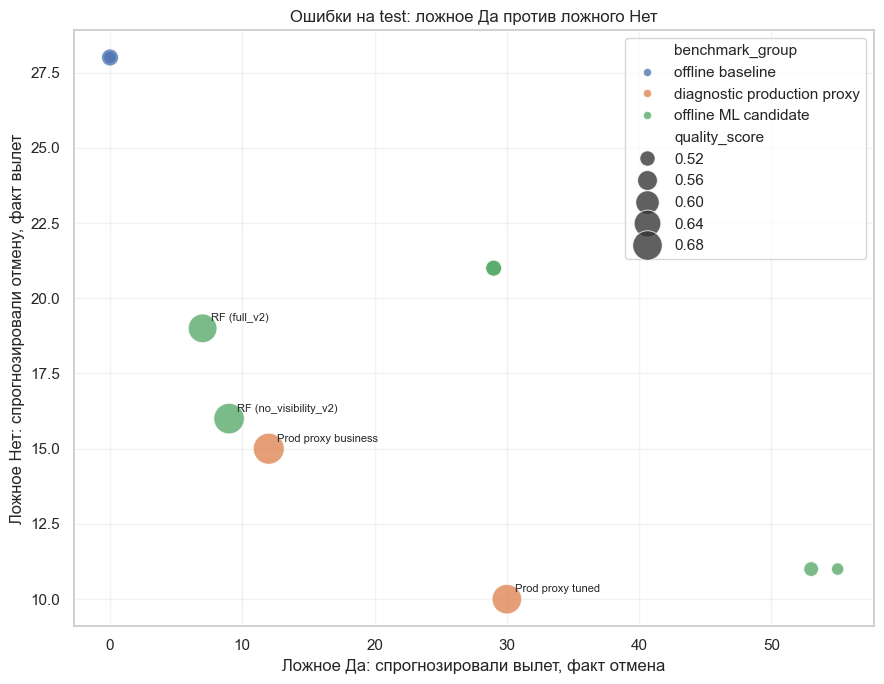

In [11]:
# False yes / false no tradeoff
tradeoff = metrics_grouped[metrics_grouped["split"] == "test"].copy()
tradeoff["short_model"] = tradeoff["model"].str.replace("Current production baseline daily proxy business threshold", "Prod proxy business", regex=False)
tradeoff["short_model"] = tradeoff["short_model"].str.replace("Current production baseline daily proxy", "Prod proxy tuned", regex=False)
tradeoff["short_model"] = tradeoff["short_model"].str.replace("RandomForest selected ", "RF ", regex=False)

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=tradeoff,
    x="false_yes",
    y="false_no",
    size="quality_score",
    hue="benchmark_group",
    sizes=(80, 500),
    alpha=0.78,
    ax=ax,
)
for _, row in tradeoff.iterrows():
    if row["quality_score"] >= tradeoff["quality_score"].quantile(0.65) or "proxy" in row["benchmark_group"]:
        ax.annotate(row["short_model"], (row["false_yes"], row["false_no"]), textcoords="offset points", xytext=(6, 5), fontsize=8)
ax.set_title("Ошибки на test: ложное Да против ложного Нет")
ax.set_xlabel("Ложное Да: спрогнозировали вылет, факт отмена")
ax.set_ylabel("Ложное Нет: спрогнозировали отмену, факт вылет")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Диагностика ошибок выбранной модели

Смотрим confusion matrix и список ошибок на test. Это помогает понять, что именно “покупает” выбранный threshold.

In [12]:
selected_threshold = float(best_valid["threshold"])
selected_proba = None
selected_dates = test_df["date"].to_numpy()

if best_model == "Constant train-rate baseline":
    selected_proba = constant_proba_test
elif best_model == "Seasonal history baseline":
    selected_proba = seasonal_proba_test
elif best_model.startswith("Current production baseline daily proxy"):
    selected_proba = proxy_proba_test
else:
    selected_model = fitted_models[(best_model, best_feature_set)]
    selected_cols = feature_set_specs[best_feature_set]
    selected_proba = class_proba_completed(selected_model, test_df[selected_cols])

selected_pred = predict_by_threshold(selected_proba, selected_threshold)
cm = confusion_matrix(y_test, selected_pred, labels=[0, 1])
display(pd.DataFrame(cm, index=["actual_cancelled", "actual_completed"], columns=["pred_cancelled", "pred_completed"]))
print(classification_report(y_test, selected_pred, target_names=["cancelled", "completed"], zero_division=0))

errors = pd.DataFrame(
    {
        "date": selected_dates,
        "actual": y_test,
        "probability_completed": selected_proba,
        "prediction": selected_pred,
    }
)
errors["error_type"] = np.select(
    [
        (errors["prediction"] == 1) & (errors["actual"] == 0),
        (errors["prediction"] == 0) & (errors["actual"] == 1),
    ],
    ["false_yes", "false_no"],
    default="hit",
)
display(errors[errors["error_type"] != "hit"].sort_values(["error_type", "date"]).head(40))

,pred_cancelled,pred_completed
actual_cancelled,78,9
actual_completed,16,12


              precision    recall  f1-score   support

   cancelled       0.83      0.90      0.86        87
   completed       0.57      0.43      0.49        28

    accuracy                           0.78       115
   macro avg       0.70      0.66      0.68       115
weighted avg       0.77      0.78      0.77       115



,date,actual,probability_completed,prediction,error_type
0,2024-01-10,1,0.244872,0,false_no
16,2024-04-01,1,0.386627,0,false_no
17,2024-04-02,1,0.352573,0,false_no
27,2024-05-10,1,0.441853,0,false_no
30,2024-06-09,1,0.384971,0,false_no
53,2024-12-14,1,0.365945,0,false_no
55,2025-01-09,1,0.305400,0,false_no
58,2025-01-31,1,0.184247,0,false_no
61,2025-03-13,1,0.309858,0,false_no
64,2025-03-24,1,0.418742,0,false_no


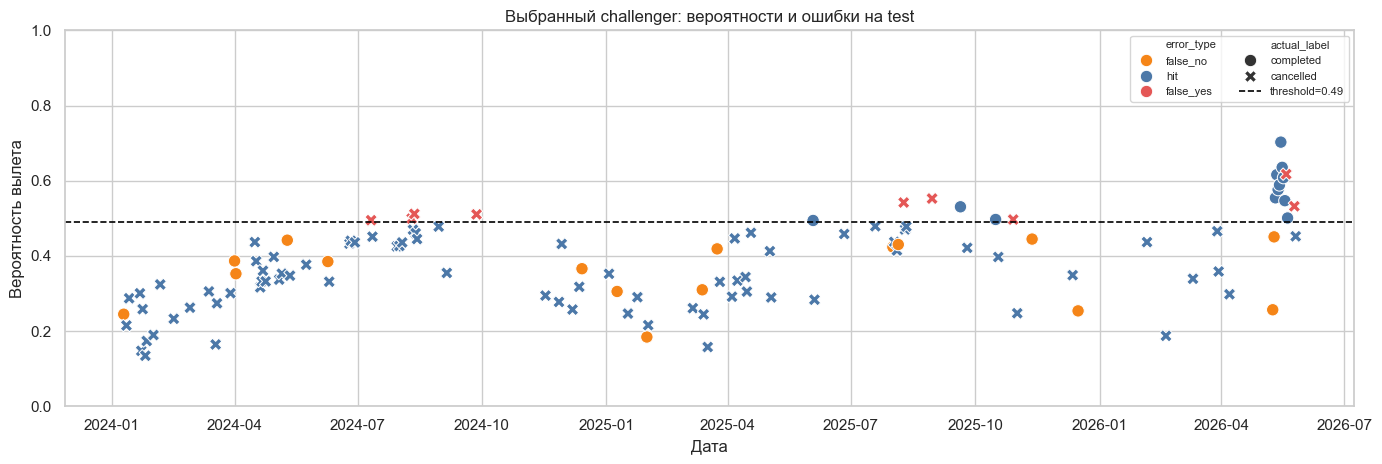

In [13]:
# Error timeline for selected challenger
error_plot = errors.copy()
error_plot["date"] = pd.to_datetime(error_plot["date"])
error_plot["actual_label"] = np.where(error_plot["actual"] == 1, "completed", "cancelled")

fig, ax = plt.subplots(figsize=(14, 4.8))
sns.scatterplot(
    data=error_plot,
    x="date",
    y="probability_completed",
    hue="error_type",
    style="actual_label",
    palette={"hit": "#4c78a8", "false_yes": "#e45756", "false_no": "#f58518"},
    s=80,
    ax=ax,
)
ax.axhline(selected_threshold, color="black", linestyle="--", linewidth=1.2, label=f"threshold={selected_threshold:.2f}")
ax.set_title("Выбранный challenger: вероятности и ошибки на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Вероятность вылета")
ax.set_ylim(0, 1)
ax.legend(loc="upper right", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 10. Калибровка

Калибровка нужна, потому что продукт показывает вероятность. Если модель выигрывает по accuracy, но вероятность плохо калибрована, её нельзя делать основной без дополнительной calibration step.

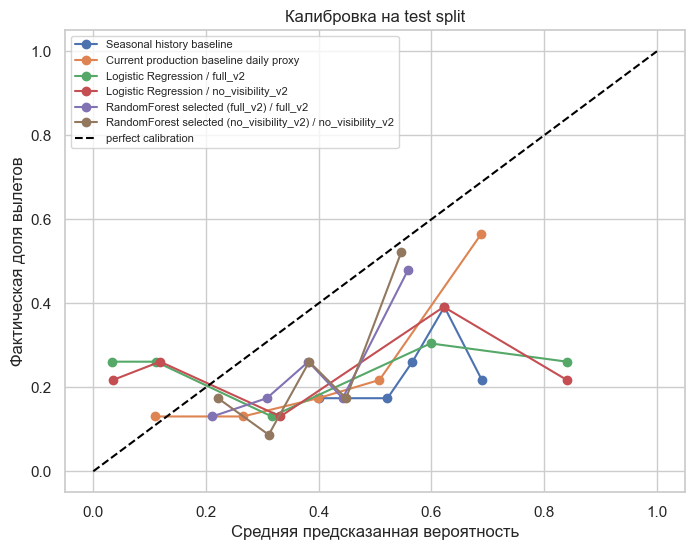

In [14]:
calibration_candidates = [
    ("Seasonal history baseline", "baseline", seasonal_proba_test),
    ("Current production baseline daily proxy", "diagnostic_proxy", proxy_proba_test),
]

for (model_name, feature_set_name), model in fitted_models.items():
    if model_name.startswith("RandomForest selected") or model_name == "Logistic Regression":
        cols = feature_set_specs[feature_set_name]
        calibration_candidates.append((f"{model_name} / {feature_set_name}", feature_set_name, class_proba_completed(model, test_df[cols])))

fig, ax = plt.subplots(figsize=(8, 6))
for label, _, proba in calibration_candidates[:8]:
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=5, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="perfect calibration")
ax.set_title("Калибровка на test split")
ax.set_xlabel("Средняя предсказанная вероятность")
ax.set_ylabel("Фактическая доля вылетов")
ax.legend(loc="best", fontsize=8)
plt.show()

## 11. Выводы текущего benchmark

Этот benchmark отвечает на вопрос: **есть ли ML-сигнал в historical day-level data?** Он не отвечает на вопрос: **готова ли ML-модель к production inference?** Для production нужны forecast snapshots и replay-протокол `(run_date, target_date, horizon_days)`.

Validation-selected winner: `RandomForest selected (no_visibility_v2)` с порогом `0.49` и параметрами `n_estimators=200`, `max_depth=8`, `min_samples_leaf=15`.

На test этот кандидат показал:

- `accuracy=0.7826`;
- `balanced_accuracy=0.6626`;
- `ROC-AUC=0.6839`;
- `PR-AUC по отменам=0.8500`;
- `Brier Score=0.1857`;
- `false_yes=9`, `false_no=16`;
- `quality_score=0.6957`.

Важный результат: лучший RF выбран именно на `no_visibility_v2`. Это подтверждает вывод из audit notebook: visibility полезна, но из-за coverage drift её нельзя бездумно считать стабильным production-признаком. Полный `full_v2` RF на test слабее по `quality_score=0.6689` и `ROC-AUC=0.6712`.

При этом ML-кандидат пока не выигрывает достаточно уверенно у diagnostic production proxy. `Current production baseline daily proxy business threshold` на test дал `quality_score=0.7031`, `ROC-AUC=0.7167`, `Brier Score=0.1892`, `false_yes=12`, `false_no=15`. RF чуть лучше по Brier и false_yes, но хуже по ROC-AUC, quality_score и false_no. Это не победа, а статус challenger.

Seasonal baseline и constant baseline слишком консервативны: они получают нормальную accuracy за счет почти постоянного `Нет`, но имеют `recall_completed=0` и `false_no=28` на test. Для пользовательского продукта это плохая политика: сервис перестает находить реальные вылеты.

ML-кандидат может перейти к production replay только если выполняются gate-критерии:

- он бьет diagnostic production proxy на validation по `quality_score` и не проигрывает по Brier Score;
- не увеличивает `false_yes` выше согласованного лимита;
- не ухудшает `false_no` так, что сервис перестает видеть реальные вылеты;
- остается стабильным на `no_visibility_v2`, а не зависит от coverage-risk visibility;
- проходит calibration check без грубой систематической ошибки вероятностей;
- проходит отдельный production replay на forecast snapshots.

Итог: на dataset v2 первый честный offline benchmark не дает основания заменять текущий baseline ML-моделью. Лучший challenger сейчас — RF без visibility, но его надо проверять следующим этапом: калибровка вероятностей, production replay dataset и forward-monitoring. До этого `mvp-baseline-007` остается более понятной и защищаемой production-логикой.


In [15]:
summary = {
    "best_validation_model": best_model,
    "best_validation_feature_set": best_feature_set,
    "best_validation_quality_score": round(float(best_valid["quality_score"]), 4),
    "best_validation_threshold": round(float(best_valid["threshold"]), 4),
}
if not test_for_best.empty:
    row = test_for_best.iloc[0]
    summary.update(
        {
            "test_accuracy": round(float(row["accuracy"]), 4),
            "test_balanced_accuracy": round(float(row["balanced_accuracy"]), 4),
            "test_roc_auc": round(float(row["roc_auc"]), 4),
            "test_pr_auc_cancelled": round(float(row["pr_auc_cancelled"]), 4),
            "test_brier_score": round(float(row["brier_score"]), 4),
            "test_false_yes": int(row["false_yes"]),
            "test_false_no": int(row["false_no"]),
            "test_quality_score": round(float(row["quality_score"]), 4),
        }
    )

baseline_test = metrics[(metrics["split"] == "test") & (metrics["model"].isin([
    "Seasonal history baseline",
    "Current production baseline daily proxy",
    "Current production baseline daily proxy business threshold",
]))].copy()
summary["baseline_test_rows"] = baseline_test[["model", "feature_set", "accuracy", "roc_auc", "brier_score", "false_yes", "false_no", "quality_score"]].round(4).to_dict("records")
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "best_validation_model": "RandomForest selected (no_visibility_v2)",
  "best_validation_feature_set": "no_visibility_v2",
  "best_validation_quality_score": 0.6883,
  "best_validation_threshold": 0.49,
  "test_accuracy": 0.7826,
  "test_balanced_accuracy": 0.6626,
  "test_roc_auc": 0.6839,
  "test_pr_auc_cancelled": 0.85,
  "test_brier_score": 0.1857,
  "test_false_yes": 9,
  "test_false_no": 16,
  "test_quality_score": 0.6957,
  "baseline_test_rows": [
    {
      "model": "Seasonal history baseline",
      "feature_set": "baseline",
      "accuracy": 0.7565,
      "roc_auc": 0.5755,
      "brier_score": 0.2853,
      "false_yes": 0,
      "false_no": 28,
      "quality_score": 0.5341
    },
    {
      "model": "Current production baseline daily proxy",
      "feature_set": "diagnostic_proxy",
      "accuracy": 0.6522,
      "roc_auc": 0.7167,
      "brier_score": 0.1892,
      "false_yes": 30,
      "false_no": 10,
      "quality_score": 0.681
    },
    {
      "model": "Curren